# Nucleus Detection

Click to open in: \[[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/nucleus-detection.ipynb)\]\[[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/nucleus-detection.ipynb)\]

## About this notebook

This jupyter notebook can be run on any computer with a standard browser and no prior installation of any programming language is required. It can run remotely over the Internet, free of charge, thanks to Google Colaboratory. To connect with Colab, click on one of the two blue checkboxes above. Check that "colab" appears in the address bar. You can right-click on "Open in Colab" and select "Open in new tab" if the left click does not work for you. Familiarize yourself with the drop-down menus near the top of the window. You can edit the notebook during the session, for example substituting your own image files for the image files used in this demo. Experiment by changing the parameters of functions. It is not possible for an ordinary user to permanently change this version of the notebook on GitHub or Colab, so you cannot inadvertently mess it up. Use the notebook's File Menu if you wish to save your own (changed) notebook.

To run the notebook on any platform, except for Colab, set up your Python environment, as explained in the
[README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package) file.


## About this demo

Each WSI can contain up to million nuclei of various types, which can be further quantified systematically and used for predicting clinical outcomes. In order to perform nuclei quantification for downstream analysis within computational pathology, nucleus detectiion and classification must be carried out as an initial step. However, this is challenging because nuclei display a high level of heterogeneity and there is significant inter- and intra-instance variability in the shape, size and chromatin pattern between and within different cell types, disease types or even from one region to another within a single tissue sample. 

> ![image](https://github.com/Jiaqi-Lv/KongNet_Inference_Main/raw/main/docs/example_zoomed_in.png)

In this example, we will demonstrate how you can use the TIAToolbox implementation of [KongNet](https://arxiv.org/abs/2510.23559) to tackle these challenges and solve the problem of nuclei detection and classification within histology images. KongNet is a a multi-headed deep learning architecture featuring a shared encoder and parallel, cell-type-specialised decoders. We validated KongNet in three Grand Challenges. It achieved first place on track 1 and second place on track 2 during the MONKEY Challenge. Its lightweight variant (KongNet-Det) secured first place in the 2025 MIDOG Challenge. KongNet ranked among the top three in the PUMA Challenge without further optimisation. Furthermore, KongNet established state-of-the-art performance on the publicly available PanNuke and CoNIC datasets.

In this example notebook, we are not going to explain how KongNet works (for more information we refer you to the [KongNet paper (currently under review)](https://arxiv.org/abs/2510.23559), but we will show how easily you can use the KongNet model to perform automatic detection and classification of nucleus instances. Mostly, we will be working with the [NucleusDetector](https://github.com/TissueImageAnalytics/tiatoolbox/blob/f852b069453f36f41bda0fb21dad4912b42d492a/tiatoolbox/models/engine/nucleus_detector.py#L140) which uses one of the pretrained [KongNet](https://github.com/TissueImageAnalytics/tiatoolbox/blob/35e9ad5119545ec9dbc86fe22e380f5b270cd258/tiatoolbox/models/architecture/kongnet.py#L464) models. We will also cover the [visualisation Interface](https://tia-toolbox.readthedocs.io/en/latest/visualization.html) embedded in TIAToolbox for overlaying the nuclei detection results on whole slide images.

## Setting up the environment

### TIAToolbox and dependencies installation

You can skip the following cell if 1) you are not using the Colab plaform or 2) you are using Colab and this is not your first run of the notebook in the current runtime session. If you nevertheless run the cell, you may get an error message, but no harm will be done. On Colab the cell installs `tiatoolbox`, and other prerequisite software. Harmless error messages should be ignored. Outside Colab , the notebook expects `tiatoolbox` to already be installed. (See the instructions in [README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package).)



In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools openslide-tools libpixman-1-dev | tail -n 1
pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
echo "Installation is done."

> **IMPORTANT**: If you are using Colab and you run the cell above for the first time, please note that you need to restart the runtime before proceeding through (menu) *"Runtime→Restart runtime"* . This is needed to load the latest versions of prerequisite packages installed with TIAToolbox. Doing so, you should be able to run all the remaining cells altogether (*"Runtime→Run after"* from the next cell) or one by one.

### Importing related libraries

We import some standard Python modules, and also the Python module `wsireader` (see [details](https://github.com/TIA-Lab/tiatoolbox/blob/master/tiatoolbox/wsicore/wsireader.py)) written by the TIA Centre team.



In [2]:
"""Import modules required to run the Jupyter notebook."""
import sys
sys.path.append("..")  # to import from parent directory
# Clear logger to use tiatoolbox.logger
import logging
import warnings

if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

import cv2
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from tiatoolbox import logger
from tiatoolbox.models.engine.nucleus_detector import NucleusDetector
from huggingface_hub import hf_hub_download

# We need this function to visualize the nuclear predictions
from tiatoolbox.utils.visualization import (
    overlay_prediction_contours,
)
from tiatoolbox.wsicore.wsireader import WSIReader

warnings.filterwarnings("ignore")
mpl.rcParams["figure.dpi"] = 300  # for high resolution figure in notebook
mpl.rcParams["figure.facecolor"] = "white"  # To make sure text is visible in dark mode
plt.rcParams.update({"font.size": 5})

|2026-01-26|18:51:01.071| [WARNING] /home/u1910100/miniconda3/envs/tiatoolbox-dev/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



### GPU or CPU runtime

Processes in this notebook can be accelerated by using a GPU. Therefore, whether you are running this notebook on your system or Colab, you need to check and specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda" or "cpu" whether you are using GPU or CPU. In Colab, you need to make sure that the runtime type is set to GPU in the *"Runtime→Change runtime type→Hardware accelerator"*. If you are *not* using GPU, consider changing the `device` flag to `cpu` value, otherwise, some errors will be raised when running the following cells.



In [3]:
device = "cuda"  # Choose appropriate device

### Removing leftovers from previous runs

The cell below removes some redundant directories if they exist—a previous run may have created them. This cell can be skipped if you are running this notebook for the first time.



In [3]:
%%bash
rm -rf ./tmp/sample_wsi_results/
echo "deleting sample_wsi_results directory"
rm -rf ./tmp/
echo "deleted tmp directory"

deleting sample_wsi_results directory
deleted tmp directory


### Downloading the required files

We download, over the internet, image files used for the purpose of this notebook. In particular, we download a whole slide image of cancerous breast tissue samples to show how the nucleus detection model works.

> In Colab, if you click the files icon (see below) in the vertical toolbar on the left hand side then you can see all the files that the code in this notebook can access. The data will appear here when it is downloaded.
>
> 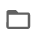


In [4]:
# These file name are used for the experimenets
tmp_dir = Path("./tmp/")

logger.info("Download has started. Please wait...")

wsi_path = hf_hub_download(
    repo_id="TIACentre/TIAToolBox_Remote_Samples",
    subfolder="sample_wsis",
    filename="D_P000019_PAS_CPG.tif",
    repo_type="dataset",
    local_dir=tmp_dir,
)

logger.info("Download is complete.")

|2026-01-26|18:51:03.600| [INFO] Download has started. Please wait...
|2026-01-26|18:51:03.957| [INFO] HTTP Request: HEAD https://huggingface.co/datasets/TIACentre/TIAToolBox_Remote_Samples/resolve/main/sample_wsis/D_P000019_PAS_CPG.tif "HTTP/1.1 302 Found"
|2026-01-26|18:51:03.958| [INFO] Download is complete.


## Mitosis Detection using TIAToolbox's pretrained KongNet model

In this section, we will demonstrate the use of the pretrained KongNet models for Mitosis Detection.


### Inference on WSIs

The next step is to use TIAToolbox's embedded model for nucleus detection on a whole slide image. The process is quite similar to what we have done for tiles. We will just introduce some important parameters that configure the instance segmentor for WSI inference.

Here we re-defined the `inst_segmentor` just to show the use of the `auto_generate_mask` parameter. By setting this parameter to `True`, we are telling TIAToolbox to automatically extract the tissue masks of the input WSIs if they are not provided in the `predict` function parameters.
In this example, we leave `auto_get_mask=False` because we are using a WSI that contains only tissue region (there is no background region) and therefore there is no need for tissue mask extraction.



In [5]:
detector = NucleusDetector(model="KongNet_MONKEY_1")

out = detector.run(
    images=[Path(wsi_path)],
    patch_mode=False,
    device="cuda",
    save_dir=tmp_dir / "sample_wsi_results/",
    overwrite=True,
    output_type="annotationstore",
    auto_get_mask=True,
    memory_threshold=75,
    num_workers=1,
    batch_size=8,
)

|2026-01-26|18:51:07.271| [INFO] HTTP Request: HEAD https://huggingface.co/TIACentre/KongNet_pretrained_weights/resolve/main/KongNet_MONKEY_1.pth "HTTP/1.1 302 Found"


|2026-01-26|18:51:09.128| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


|2026-01-26|18:51:09.332| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-01-26|18:51:09.464| [WARNING] Metadata: Objective power inferred from microns-per-pixel (MPP).


Inferring patches:   0%|          | 0/326 [00:00<?, ?it/s]

: 

In [ ]:
from tiatoolbox.annotation.storage import SQLiteStore

store_path = "/media/u1910100/data/overlays/test/wsi1_2k_2k.db"
store = SQLiteStore.open(store_path)

for ann in store.values():
    logger.info(ann)